[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter4_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 4: Cointegration revisited: VECM, ARDL and panel data

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The cointegrated VAR as reduced-rank regression; the five deterministic cases and their null distributions.
- Small samples: Reinsel–Ahn correction and the wild bootstrap rank test.
- Interest-rate pass-through in Romania: rank, restrictions on beta and alpha.
- I(2) check; common trends (King, Plosser, Stock and Watson 1991).
- ARDL and the bounds test with asymptotic and small-sample critical values.
- Panel time series for EU-27: CD, LLC/IPS/CIPS, Pedroni and Westerlund, MG/PMG/CCE.
- Simulation sizes and bootstrap replications are reduced here to keep the run short.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_4'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- Johansen: `vecm_design`, `johansen`, `vecm_fit`, `restricted_ml`, `weak_exog_lr`, `lr_beta`, `granger_C`, `perp`.
- Critical values: `sim_trace_null`, `trace_tables`, `crit_table` (simulated quantiles, cases 1–5).
- Small samples: `reinsel_ahn`, `vecm_simulate`, `boot_trace` (wild bootstrap under H(r)).
- ARDL: `ardl_ecm`, `ardl_select`, `bounds_sim`, `bounds_quantiles`.

In [5]:
import io
import urllib.error
from scipy import optimize
SEED = 2026
IMF_IR = 'https://api.imf.org/external/sdmx/2.1/data/IMF.STA,MFS_IR/{c}..M'
IMF_LEND = 'MFS162_RT_PT_A_PT'
IMF_DEP = 'MFS135_RT_PT_A_PT'
R3M = 'irt_st_m'
PT = {'start': '2005-08-01', 'end': '2026-03-01', 'pmax': 8, 'case': 2}
KPSW = {'start': '1949-01-01', 'end': '1988-10-01', 'pmax': 8, 'case': 3, 'H': 24}
EU27 = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
PANEL = {'start': 1995, 'end': 2024}
NSIM = 10000
CASES = {1: 'no deterministic terms', 2: 'restricted constant', 3: 'unrestricted constant', 4: 'restricted trend', 5: 'unrestricted trend'}
PSS_CASES = {1: 'no intercept, no trend', 2: 'restricted intercept', 3: 'unrestricted intercept', 4: 'unrestricted intercept, restricted trend', 5: 'unrestricted intercept and trend'}
_FILES = {}
_TAB = {}
HERE = '.'


def get_bytes(url):
    """Download a public file once per session (no key); optional local cache folder ATS_CACHE."""
    import hashlib
    import time
    if url in _FILES:
        return _FILES[url]
    cache = os.environ.get('ATS_CACHE')
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _FILES[url] = open(path, 'rb').read()
        return _FILES[url]
    for attempt in range(5):
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _FILES[url] = urllib.request.urlopen(req, timeout=300).read()
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 4:
                raise
            time.sleep(10 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_FILES[url])
    return _FILES[url]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def patch(c, a=0.25):
    from matplotlib.patches import Patch
    return Patch(facecolor=c, alpha=a, edgecolor='none')


def vecm_design(Y, p, case, exog=None):
    """Z0 = dY_t, Z1 = (Y_{t-1}, restricted deterministic term), Z2 = (dY_{t-1..t-p+1}, unrestricted terms).
    Case 1: none; 2: constant in Z1; 3: constant in Z2; 4: trend in Z1, constant in Z2; 5: constant and trend in Z2.
    Y is T x n (levels); p is the lag order of the VAR in levels."""
    Y = np.asarray(Y, float)
    T, n = Y.shape
    dY = np.diff(Y, axis=0)
    t = np.arange(p, T)
    Z0 = dY[p - 1:]
    Z1 = Y[p - 1:T - 1]
    Z2 = [dY[p - 1 - j:T - 1 - j] for j in range(1, p)]
    one = np.ones((T - p, 1))
    trend = (t - p + 1.0)[:, None]
    if case == 2:
        Z1 = np.hstack([Z1, one])
    if case == 4:
        Z1 = np.hstack([Z1, trend])
    if case in (3, 4, 5):
        Z2.append(one)
    if case == 5:
        Z2.append(trend)
    if exog is not None:
        Z2.append(np.asarray(exog, float)[p:])
    Z2 = np.hstack(Z2) if Z2 else np.zeros((T - p, 0))
    return Z0, Z1, Z2


def resid(A, B):
    if B.shape[1] == 0:
        return A
    return A - B @ np.linalg.lstsq(B, A, rcond=None)[0]


def johansen(Y, p, case=3, exog=None):
    """Johansen (1988, 1991) reduced-rank regression. Returns eigenvalues (descending), beta (normalised
    beta'S11 beta = I), alpha, trace and max-eigenvalue statistics, the moment matrices and the design."""
    Z0, Z1, Z2 = vecm_design(Y, p, case, exog)
    R0, R1 = resid(Z0, Z2), resid(Z1, Z2)
    T = len(R0)
    S00, S01, S11 = R0.T @ R0 / T, R0.T @ R1 / T, R1.T @ R1 / T
    L = np.linalg.cholesky(S11)
    Li = np.linalg.inv(L)
    M = Li @ S01.T @ np.linalg.solve(S00, S01) @ Li.T
    lam, V = np.linalg.eigh((M + M.T) / 2)
    o = np.argsort(lam)[::-1]
    lam, V = np.clip(lam[o], 0, 1 - 1e-12), V[:, o]
    beta = Li.T @ V
    n = Z0.shape[1]
    lam = lam[:n]
    beta = beta[:, :n]
    alpha = S01 @ beta
    trace = np.array([-T * np.log(1 - lam[r:]).sum() for r in range(n)])
    maxeig = -T * np.log(1 - lam)
    return dict(lam=lam, beta=beta, alpha=alpha, trace=trace, maxeig=maxeig, S00=S00, S01=S01, S11=S11, T=T, n=n,
                p=p, case=case, Z0=Z0, Z1=Z1, Z2=Z2, R0=R0, R1=R1)


def vecm_fit(Y, p, r, case=3, exog=None, beta=None):
    """ML estimates of the VECM with rank r (beta from Johansen unless given): alpha, Gamma (short-run and
    unrestricted deterministic coefficients), residuals and Omega."""
    j = johansen(Y, p, case, exog)
    b = j['beta'][:, :r] if beta is None else np.asarray(beta, float).reshape(j['Z1'].shape[1], r)
    Z0, Z1, Z2 = j['Z0'], j['Z1'], j['Z2']
    ec = Z1 @ b
    X = np.hstack([ec, Z2])
    C = np.linalg.lstsq(X, Z0, rcond=None)[0]
    alpha = C[:r].T
    G = C[r:].T
    U = Z0 - X @ C
    return dict(alpha=alpha, beta=b, G=G, U=U, Omega=U.T @ U / len(U), j=j, r=r, p=p, case=case, exog=exog,
                Y=np.asarray(Y, float))


def logdet(A):
    return float(np.linalg.slogdet(A)[1])


def lr_beta(j, r, betas):
    """LR statistic of a fully specified beta (Z1-dimension x r): T[log|Omega(beta)| - log|S00| - sum log(1-lam)]."""
    S00, S01, S11, T = j['S00'], j['S01'], j['S11'], j['T']
    b = np.asarray(betas, float)
    Om = S00 - S01 @ b @ np.linalg.solve(b.T @ S11 @ b, b.T @ S01.T)
    return T * (logdet(Om) - logdet(S00) - np.log(1 - j['lam'][:r]).sum())


def partial_moments(j, A):
    """Moment matrices of the system under alpha = A psi (Johansen 1995, Ch. 8): the rows of R0 orthogonal to A are
    conditioned on. Returns S_aa.b, S_a1.b, S_11.b and log|S_bb| + the log-determinant correction."""
    n = A.shape[0]
    Abar = A @ np.linalg.inv(A.T @ A)
    if A.shape[1] == n:
        return j['S00'], j['S01'], j['S11'], 0.0
    Bp = np.linalg.svd(A.T)[2][A.shape[1]:].T            # A-perp
    Ra, Rb = j['R0'] @ Abar, j['R0'] @ Bp
    R1 = j['R1']
    T = len(Ra)
    Ra_b, R1_b = resid(Ra, Rb), resid(R1, Rb)
    Saa, Sa1, S11 = Ra_b.T @ Ra_b / T, Ra_b.T @ R1_b / T, R1_b.T @ R1_b / T
    const = logdet(Rb.T @ Rb / T) - 2 * logdet(np.hstack([Abar, Bp]))
    return Saa, Sa1, S11, const


def restricted_ml(j, r, H_list, h_list, A=None, x0=None):
    """ML under beta_i = H_i phi_i + h_i (i = 1..r; h_i carries the normalisation) and alpha = A psi, by numerical
    maximisation of the concentrated likelihood. Returns the LR statistic against the unrestricted rank-r model,
    the restricted beta and the maximised -2 log L / T (up to a constant)."""
    n = j['n']
    A = np.eye(n) if A is None else np.asarray(A, float)
    Saa, Sa1, S11, const = partial_moments(j, A)
    sizes = [H.shape[1] for H in H_list]

    def make(phi):
        cols, k = [], 0
        for H, h, s in zip(H_list, h_list, sizes):
            cols.append(H @ phi[k:k + s] + h)
            k += s
        return np.column_stack(cols)

    def f(phi):
        b = make(phi)
        BS = b.T @ S11 @ b
        if np.linalg.cond(BS) > 1e12:
            return 1e6
        return logdet(Saa - Sa1 @ b @ np.linalg.solve(BS, b.T @ Sa1.T)) + const

    k = sum(sizes)
    if k == 0:
        val, b = f(np.zeros(0)), make(np.zeros(0))
    else:
        best = None
        rng = np.random.default_rng(SEED)
        starts = [np.zeros(k) if x0 is None else np.asarray(x0, float)] + [rng.normal(0, 1, k) for _ in range(8)]
        for s0 in starts:
            res = optimize.minimize(f, s0, method='BFGS')
            if best is None or res.fun < best.fun:
                best = res
        val, b = best.fun, make(best.x)
    T = j['T']
    LR = T * (val - logdet(j['S00']) - np.log(1 - j['lam'][:r]).sum())
    return dict(LR=float(LR), beta=b, value=float(val))


def weak_exog_lr(j, r, A):
    """LR test of alpha = A psi with beta unrestricted: T sum log((1 - lam_tilde_i)/(1 - lam_i)) (Johansen 1995)."""
    Saa, Sa1, S11, _ = partial_moments(j, np.asarray(A, float))
    L = np.linalg.cholesky(S11)
    Li = np.linalg.inv(L)
    M = Li @ Sa1.T @ np.linalg.solve(Saa, Sa1) @ Li.T
    lt = np.sort(np.linalg.eigvalsh((M + M.T) / 2))[::-1][:r]
    return float(j['T'] * np.log((1 - lt) / (1 - j['lam'][:r])).sum())


def var_from_vecm(alpha, beta_y, G, p, n):
    """Levels VAR(p) slope matrices from the VECM: A1 = I + alpha beta' + Gamma1, Ai = Gamma_i - Gamma_{i-1},
    Ap = -Gamma_{p-1}. beta_y: the rows of beta that multiply Y_{t-1}."""
    Gam = [G[:, n * i:n * (i + 1)] for i in range(p - 1)]
    Pi = alpha @ beta_y.T
    A = []
    for i in range(p):
        Ai = (np.eye(n) + Pi if i == 0 else np.zeros((n, n)))
        if i < p - 1:
            Ai = Ai + Gam[i]
        if i > 0:
            Ai = Ai - Gam[i - 1]
        A.append(Ai)
    return np.stack(A)


def ma_coefs(A, H):
    """Reduced-form MA coefficients Phi_0..Phi_H (Phi_0 = I) of a VAR in levels (need not be stable)."""
    p, n, _ = A.shape
    Phi = np.zeros((H + 1, n, n))
    Phi[0] = np.eye(n)
    for h in range(1, H + 1):
        Phi[h] = sum(A[j] @ Phi[h - j - 1] for j in range(min(p, h)))
    return Phi


def perp(M):
    """Orthogonal complement of the columns of M (n x r) -> n x (n - r)."""
    u, s, vt = np.linalg.svd(M)
    return u[:, M.shape[1]:]


def granger_C(alpha, beta_y, G, p, n):
    """Long-run impact matrix of the Granger representation: C = beta_perp (alpha_perp' Gamma beta_perp)^{-1}
    alpha_perp', Gamma = I - sum Gamma_i."""
    Gam = np.eye(n) - sum(G[:, n * i:n * (i + 1)] for i in range(p - 1)) if p > 1 else np.eye(n)
    ap, bp = perp(alpha), perp(beta_y)
    return bp @ np.linalg.solve(ap.T @ Gam @ bp, ap.T)


def lag_select(Y, pmax, case=3, exog=None):
    """AIC, BIC and HQ of VARs in levels with p = 1..pmax on a common sample (constant included)."""
    Y = np.asarray(Y, float)
    out = {}
    T, n = Y.shape
    for p in range(1, pmax + 1):
        Yt = Y[pmax:]
        X = np.hstack([Y[pmax - j:T - j] for j in range(1, p + 1)] + [np.ones((T - pmax, 1))])
        U = Yt - X @ np.linalg.lstsq(X, Yt, rcond=None)[0]
        S = U.T @ U / len(U)
        k = X.shape[1] * n
        ld = logdet(S)
        out[p] = dict(aic=ld + 2 * k / len(U), bic=ld + np.log(len(U)) * k / len(U),
                      hq=ld + 2 * np.log(np.log(len(U))) * k / len(U))
    return {c: int(min(out, key=lambda q: out[q][c])) for c in ('aic', 'bic', 'hq')}


def sim_trace_null(m, case, T=400, reps=NSIM, seed=SEED):
    """Null distribution of the trace statistic for H(r) against H(n) when n - r = m, simulated from m independent
    random walks (with a drift in cases 3 and 5, the configuration for which these cases are tabulated) and a VAR(1)
    test regression. T = 400 approximates the asymptotic distribution."""
    rng = np.random.default_rng(seed + 100 * case + m)
    out = np.empty(reps)
    for k in range(reps):
        e = rng.standard_normal((T, m))
        if case == 3:
            e = e + 1.0
        if case == 5:
            e = e + 1.0 + 0.02 * np.arange(T)[:, None]
        Y = np.cumsum(e, axis=0)
        out[k] = johansen(Y, 1, case)['trace'][0]
    return out


def trace_tables(ms=(1, 2, 3, 4), reps=NSIM):
    """90%, 95% and 99% quantiles of the simulated trace distributions, cases 1-5, n - r = 1..4."""
    tab = {}
    draws = {}
    for case in range(1, 6):
        for m in ms:
            d = sim_trace_null(m, case, reps=reps)
            draws[(case, m)] = d
            tab[f'{case}|{m}'] = [float(np.quantile(d, q)) for q in (0.90, 0.95, 0.99)]
    return tab, draws


def crit_table():
    """The simulated 90/95/99% quantiles of the trace statistic (cases 1-5, n - r = 1..4), computed once per session
    (or read from ch4_numbers.json when it exists, so that every slide uses the same table)."""
    if not _TAB:
        path = os.path.join(HERE, 'ch4_numbers.json') if 'HERE' in globals() else ''
        if path and os.path.exists(path) and 'trace' in json.load(open(path)):
            _TAB.update(json.load(open(path))['trace']['table'])
        else:
            _TAB.update(trace_tables(reps=NSIM)[0])
    return _TAB


def pvalue(stat, draws):
    return float((np.sum(draws >= stat) + 1) / (len(draws) + 1))


def ols(y, X):
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    u = y - X @ b
    s2 = u @ u / (len(y) - X.shape[1])
    V = s2 * np.linalg.inv(X.T @ X)
    return b, V, u


def ardl_ecm(y, x, p, q, case=3, start=None):
    """Conditional ECM of an ARDL(p, q) (PSS 2001, eq. 6):
    dy_t = det + pi_y y_{t-1} + pi_x' x_{t-1} + sum_{i<p} psi_i dy_{t-i} + sum_{j<q} omega_j' dx_{t-j} + u_t.
    y: (T,), x: (T, k). Returns F (bounds F statistic), t (t-ratio of pi_y), the long-run coefficients
    theta = -pi_x/pi_y with delta-method standard errors, the speed of adjustment pi_y, information criteria and the
    fitted pieces. `start` fixes the first usable observation (common sample for lag selection)."""
    y = np.asarray(y, float)
    x = np.asarray(x, float).reshape(len(y), -1)
    T, k = x.shape
    m = max(p, q, 1)
    s = start if start is not None else m
    dy, dx = np.diff(y, prepend=np.nan), np.diff(x, axis=0, prepend=np.nan)
    rows = np.arange(s, T)
    cols, names = [], []
    tt = rows.astype(float)
    if case == 2:
        cols.append(np.ones(len(rows)))
        names.append('c_r')
    if case in (3, 4, 5):
        cols.append(np.ones(len(rows)))
        names.append('c')
    if case == 4:
        cols.append(tt)
        names.append('t_r')
    if case == 5:
        cols.append(tt)
        names.append('t')
    cols.append(y[rows - 1])
    names.append('y1')
    for i in range(k):
        cols.append(x[rows - 1, i])
        names.append(f'x1_{i}')
    for i in range(1, p):
        cols.append(dy[rows - i])
        names.append(f'dy{i}')
    for i in range(k):
        for j in range(q):
            cols.append(dx[rows - j, i])
            names.append(f'dx{j}_{i}')
    X = np.column_stack(cols)
    b, V, u = ols(dy[rows], X)
    test = [nm for nm in names if nm in ('c_r', 't_r', 'y1') or nm.startswith('x1_')]
    idx = [names.index(nm) for nm in test]
    R = np.zeros((len(idx), len(b)))
    R[np.arange(len(idx)), idx] = 1
    F = float((R @ b) @ np.linalg.solve(R @ V @ R.T, R @ b) / len(idx))
    iy = names.index('y1')
    ix = [names.index(f'x1_{i}') for i in range(k)]
    piy = b[iy]
    theta = -b[ix] / piy
    se_th = []
    for i in ix:
        g = np.zeros(len(b))
        g[i] = -1 / piy
        g[iy] = b[i] / piy ** 2
        se_th.append(float(np.sqrt(g @ V @ g)))
    n = len(u)
    sig2 = u @ u / n
    return dict(F=F, t=float(piy / np.sqrt(V[iy, iy])), theta=theta, se_theta=np.array(se_th), phi=float(piy),
                se_phi=float(np.sqrt(V[iy, iy])), aic=float(np.log(sig2) + 2 * len(b) / n),
                bic=float(np.log(sig2) + np.log(n) * len(b) / n), b=b, V=V, u=u, names=names, n=n, p=p, q=q, case=case,
                halflife=float(np.log(0.5) / np.log(1 + piy)) if -1 < piy < 0 else np.nan)


def ardl_select(y, x, pmax=6, qmax=6, case=3, crit='aic'):
    """Lag orders by AIC or BIC on a common sample (start = max lag)."""
    m = max(pmax, qmax)
    best = None
    for p in range(1, pmax + 1):
        for q in range(1, qmax + 1):
            r = ardl_ecm(y, x, p, q, case, start=m)
            if best is None or r[crit] < best[crit]:
                best = r
    return ardl_ecm(y, x, best['p'], best['q'], case)


def bounds_sim(k, case, T=1000, reps=NSIM, seed=SEED, which='F'):
    """Null distribution of the bounds F (or t) statistic: y a random walk unrelated to x; x either k independent
    random walks (the I(1) bound) or k i.i.d. N(0,1) series (the I(0) bound). Regression dy_t on the deterministic
    terms of the case, y_{t-1}, x_{t-1} (short-run terms do not affect the limit). Returns (I(0) draws, I(1) draws)."""
    rng = np.random.default_rng(seed + 10 * case + k + T)
    out = {0: np.empty(reps), 1: np.empty(reps)}
    for bnd in (0, 1):
        for r in range(reps):
            y = np.cumsum(rng.standard_normal(T + 1))
            e = rng.standard_normal((T + 1, k))
            x = np.cumsum(e, axis=0) if bnd == 1 else e
            out[bnd][r] = ardl_ecm(y, x, 1, 0, case)[which]
    return out[0], out[1]


def bounds_quantiles(k, case, T=1000, reps=NSIM, which='F'):
    lo, hi = bounds_sim(k, case, T, reps, which=which)
    qs = (0.90, 0.95, 0.99) if which == 'F' else (0.10, 0.05, 0.01)
    return {f'{q:.2f}': [float(np.quantile(lo, q)), float(np.quantile(hi, q))] for q in qs}


def reinsel_ahn(trace, T, n, p):
    """Reinsel and Ahn (1992): the trace statistic scaled by (T - n p)/T."""
    return trace * (T - n * p) / T


def vecm_simulate(m, e):
    """Levels generated recursively from a fitted VECM with innovations e (T_eff x n), initial values and
    deterministic terms taken from the estimation sample."""
    Y, j, n, p = m['Y'], m['j'], m['j']['n'], m['p']
    Z1d, Z2d = j['Z1'][:, n:], j['Z2'][:, n * (p - 1):]
    T = len(e)
    Yb = np.zeros((T + p, n))
    Yb[:p] = Y[:p]
    for k in range(T):
        t = p + k
        z1 = np.concatenate([Yb[t - 1], Z1d[k]])
        dyl = [Yb[t - i] - Yb[t - i - 1] for i in range(1, p)]
        z2 = np.concatenate(dyl + [Z2d[k]]) if dyl else Z2d[k]
        Yb[t] = Yb[t - 1] + m['alpha'] @ (m['beta'].T @ z1) + m['G'] @ z2 + e[k]
    return Yb


def boot_trace(Y, p, r, case=2, B=399, seed=SEED, wild=True, exog=None):
    """Bootstrap p-value of the trace test of H(r) (Swensen 2006; wild bootstrap of Cavaliere, Rahbek and Taylor
    2010, 2012): the VECM is estimated under H(r), data are regenerated recursively with residuals multiplied by
    N(0, 1) draws (wild) or resampled (i.i.d.), and the trace statistic is recomputed on each bootstrap sample."""
    j = johansen(Y, p, case, exog)
    stat = j['trace'][r]
    m = vecm_fit(Y, p, r, case, exog)
    rng = np.random.default_rng(seed)
    U = m['U']
    T = len(U)
    cnt, done = 0, 0
    for _ in range(B):
        e = U * rng.standard_normal((T, 1)) if wild else (U - U.mean(0))[rng.integers(0, T, T)]
        Yb = vecm_simulate(m, e)
        try:
            sb = johansen(Yb, p, case, exog)['trace'][r]
        except np.linalg.LinAlgError:
            continue
        cnt += sb >= stat
        done += 1
    return float(stat), float((cnt + 1) / (done + 1))

## 1. The five deterministic cases: simulated null distributions

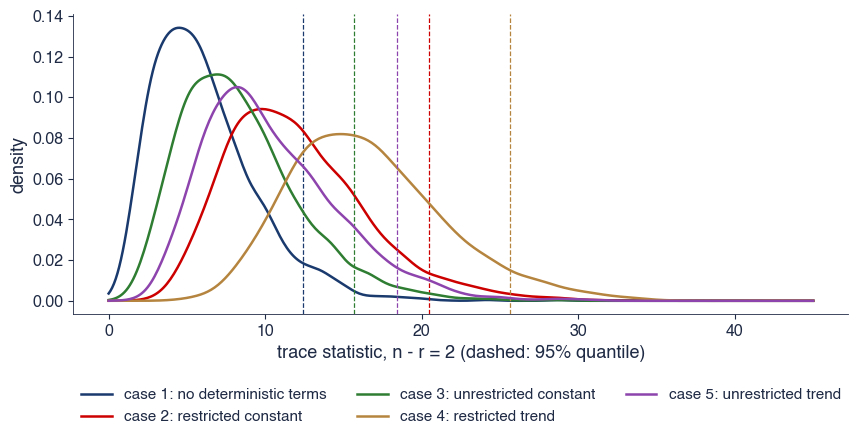

{'1|1': [3.01, 4.12, 7.23], '1|2': [10.43, 12.41, 15.94], '1|3': [22.35, 24.75, 29.81], '1|4': [37.04, 40.19, 45.44], '2|1': [7.4, 9.07, 13.0], '2|2': [17.86, 20.45, 25.3], '2|3': [31.93, 35.22, 40.94], '2|4': [50.68, 54.04, 61.42], '3|1': [2.83, 4.07, 6.29], '3|2': [13.67, 15.67, 20.11], '3|3': [26.8, 29.96, 35.21], '3|4': [44.69, 47.85, 54.36], '4|1': [10.73, 12.37, 16.6], '4|2': [23.32, 25.65, 30.69], '4|3': [40.61, 44.17, 50.84], '4|4': [60.13, 64.04, 72.06], '5|1': [2.8, 3.97, 6.89], '5|2': [16.13, 18.41, 22.73], '5|3': [32.53, 35.38, 42.22], '5|4': [51.79, 55.79, 63.51]}


In [6]:
def fig_trace_dists(save_it=True, reps=NSIM):
    """Simulated null distributions of the trace statistic (n - r = 2) in the five deterministic cases, and the
    table of 90/95/99% quantiles for n - r = 1..4."""
    tab, draws = trace_tables(reps=reps)
    _TAB.clear()
    _TAB.update(tab)
    fig, ax = plt.subplots(figsize=(10, 3.9))
    cols = [st.MainBlue, st.IDAred, st.Forest, st.Amber, st.Purple]
    grid = np.linspace(0, 45, 400)
    for case, c in zip(range(1, 6), cols):
        d = draws[(case, 2)]
        kde = stats.gaussian_kde(d)
        ax.plot(grid, kde(grid), color=c, lw=1.8, label=f'case {case}: {CASES[case]}')
        ax.axvline(np.quantile(d, 0.95), color=c, lw=0.9, ls='--')
    ax.set_xlabel('trace statistic, n - r = 2 (dashed: 95% quantile)')
    ax.set_ylabel('density')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch4_trace_dists', save_it)
    return dict(table=tab, reps=reps)


r = fig_trace_dists(save_it=False, reps=3000)
print({k: [round(x, 2) for x in v] for k, v in r['table'].items()})

## 2. Size of the rank test in small samples

- 60 replications with 99 bootstrap samples here (400 and 199 on the slides).

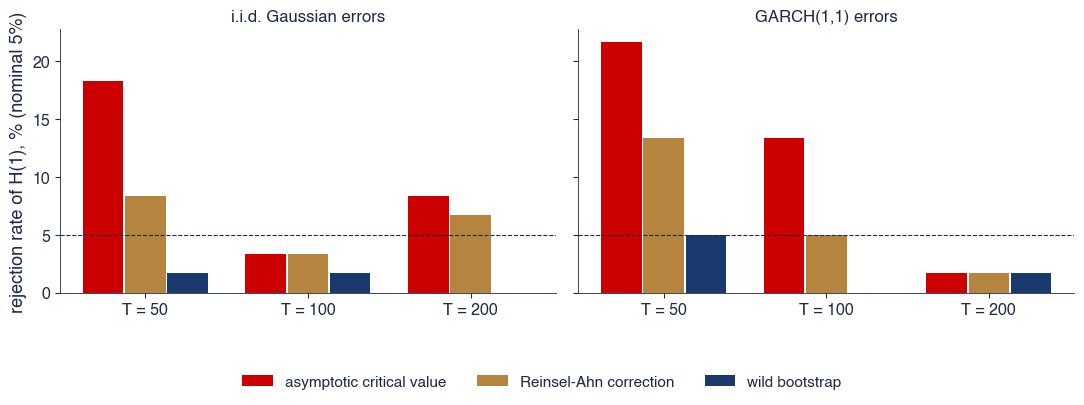

{'iid': {'50': [0.18333333333333332, 0.08333333333333333, 0.016666666666666666], '100': [0.03333333333333333, 0.03333333333333333, 0.016666666666666666], '200': [0.08333333333333333, 0.06666666666666667, 0.0]}, 'garch': {'50': [0.21666666666666667, 0.13333333333333333, 0.05], '100': [0.13333333333333333, 0.05, 0.0], '200': [0.016666666666666666, 0.016666666666666666, 0.016666666666666666]}, 'reps': 60, 'B': 99, 'crit': 20.532833145977843}


In [7]:
def mc_dgp(T, rng, n=3, burn=50, het=False):
    """Monte Carlo DGP: a three-variable VECM with one cointegrating relation, beta = (1, -1, 0)',
    alpha = (-0.2, 0.1, 0)', Gamma_1 = 0.8 I (persistent short run); optional GARCH(1,1) errors."""
    alpha = np.array([[-0.2], [0.1], [0.0]])
    beta = np.array([[1.0], [-1.0], [0.0]])
    G1 = 0.8 * np.eye(n)
    Y = np.zeros((T + burn, n))
    dy_prev = np.zeros(n)
    h = np.ones(n)
    e_prev = np.zeros(n)
    for t in range(1, T + burn):
        z = rng.standard_normal(n)
        if het:
            h = 0.05 + 0.15 * e_prev ** 2 + 0.8 * h
            e = np.sqrt(h) * z
        else:
            e = z
        dy = (alpha @ beta.T @ Y[t - 1]) + G1 @ dy_prev + e
        Y[t] = Y[t - 1] + dy
        dy_prev, e_prev = dy, e
    return Y[burn:]


def mc_size(Ts=(50, 100, 200), reps=300, B=199, seed=SEED, crit=None, het=False):
    """Rejection frequency of H(1) at 5% (true rank 1, case 2, VAR(2)): asymptotic critical value, Reinsel-Ahn
    correction and the wild bootstrap."""
    rng = np.random.default_rng(seed)
    out = {}
    for T in Ts:
        rej = np.zeros(3)
        for k in range(reps):
            Y = mc_dgp(T, rng, het=het)
            j = johansen(Y, 2, 2)
            s = j['trace'][1]
            rej[0] += s > crit
            rej[1] += reinsel_ahn(s, j['T'], 3, 2) > crit
            rej[2] += boot_trace(Y, 2, 1, 2, B=B, seed=int(rng.integers(1e9)))[1] < 0.05
        out[T] = (rej / reps).tolist()
    return out


def fig_size_mc(save_it=True, reps=400, B=199, crit=None):
    """Monte Carlo size of the trace test of H(1) at 5%: asymptotic, Reinsel-Ahn and wild bootstrap."""
    if crit is None:
        crit = float(np.quantile(sim_trace_null(2, 2, reps=NSIM), 0.95))
    Ts = (50, 100, 200)
    res = mc_size(Ts, reps=reps, B=B, crit=crit)
    resh = mc_size(Ts, reps=reps, B=B, crit=crit, het=True, seed=SEED + 1)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.7), sharey=True)
    labs = ['asymptotic critical value', 'Reinsel-Ahn correction', 'wild bootstrap']
    for ax, r, ttl in ((axs[0], res, 'i.i.d. Gaussian errors'), (axs[1], resh, 'GARCH(1,1) errors')):
        x = np.arange(len(Ts))
        for k, (lab, c) in enumerate(zip(labs, [st.IDAred, st.Amber, st.MainBlue])):
            ax.bar(x + (k - 1) * 0.26, [100 * r[T][k] for T in Ts], width=0.25, color=c, label=lab)
        ax.axhline(5, color=st.DarkText, lw=0.8, ls='--')
        ax.set_xticks(x)
        ax.set_xticklabels([f'T = {T}' for T in Ts])
        ax.set_title(ttl, fontsize=12)
    axs[0].set_ylabel('rejection rate of H(1), % (nominal 5%)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch4_size_mc', save_it)
    return dict(iid={str(k): v for k, v in res.items()}, garch={str(k): v for k, v in resh.items()}, reps=reps, B=B, crit=crit)


print(fig_size_mc(save_it=False, reps=60, B=99))

## 3. Interest-rate pass-through in Romania

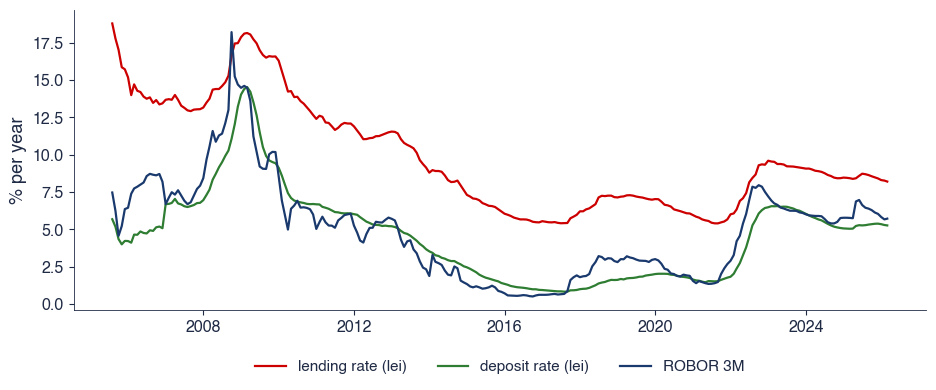

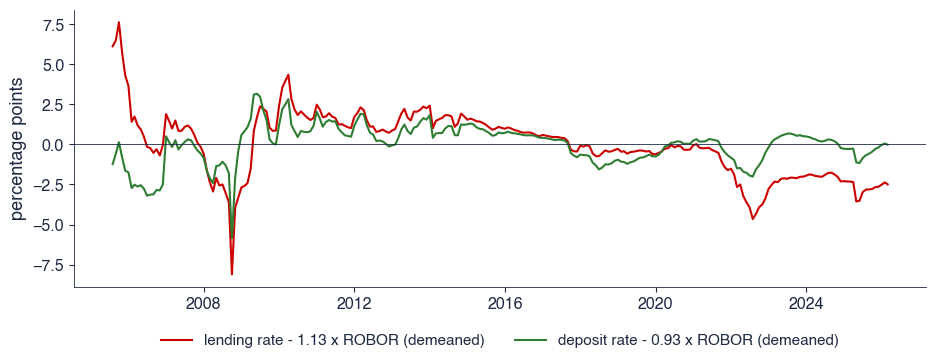

{'T': 248, 'p': 2, 'ic': {'aic': 8, 'bic': 2, 'hq': 5}, 'trace2': [121.09590593798606, 52.1926676449542, 4.295989986821649], 'boot': [0.0075, 0.0225, 0.7675], 'theta_l': 1.1251861498330753, 'theta_d': 0.9312812330250976, 'pc': 0.011200911296729288, 'pl': 0.04138121218711066, 'pw': 0.7520563736632494}


In [8]:
def read_imf_rates(country):
    """Monthly interest rates of one country from the IMF data API (International Financial Statistics, dataset
    MFS_IR; public SDMX, no key). country: ISO3 code, e.g. 'ROU'. Returns a DataFrame, one column per indicator."""
    xml = get_bytes(IMF_IR.format(c=country)).decode('utf-8', 'ignore')
    out = {}
    for m in re.finditer(r'<Series ([^>]*)>(.*?)</Series>', xml, re.S):
        ind = re.search(r'INDICATOR="(\w+)"', m.group(1)).group(1)
        obs = re.findall(r'TIME_PERIOD="(\d{4})-M(\d{2})" OBS_VALUE="([^"]+)"', m.group(2))
        if obs:
            out[ind] = pd.Series({pd.Timestamp(int(y), int(mm), 1): float(v) for y, mm, v in obs}).sort_index()
    return pd.DataFrame(out)


def passthrough_data(geo='RO', iso='ROU', start=PT['start'], end=PT['end']):
    """Lending rate and deposit rate (IMF IFS, national-currency business, % p.a.) and the 3-month money-market rate
    (Eurostat irt_st_m: ROBOR, PRIBOR, BUBOR), monthly. Isolated missing months of the money-market rate (BUBOR has
    19 in 2006-2013) are filled by linear interpolation (at most two consecutive months)."""
    imf = read_imf_rates(iso)
    r3 = read_eurostat(R3M, f'M.IRT_M3.{geo}')
    r3 = r3.reindex(pd.date_range(r3.index[0], r3.index[-1], freq='MS')).interpolate(limit=2, limit_area='inside')
    d = pd.concat([imf[IMF_LEND], imf[IMF_DEP], r3], axis=1, keys=['lend', 'dep', 'mm']).loc[start:end]
    return d.dropna()


def passthrough_tests(d, p, case=2):
    """Rank-2 pass-through VECM (lending, deposit, money-market rate): just-identified beta (lending excludes the
    deposit rate, deposit excludes the lending rate), LR tests of complete pass-through and weak exogeneity."""
    Y = d[['lend', 'dep', 'mm']].values
    j = johansen(Y, p, case)
    nz = j['Z1'].shape[1]
    free = np.zeros((nz, 2 if case == 2 else 1))
    free[2, 0] = 1
    if case == 2:
        free[3, 1] = 1
    e = np.eye(nz)
    ji = restricted_ml(j, 2, [free, free], [e[0], e[1]])
    fixed = np.zeros((nz, 1 if case == 2 else 0))
    if case == 2:
        fixed[3, 0] = 1
    jc = restricted_ml(j, 2, [fixed, fixed], [e[0] - e[2], e[1] - e[2]])
    jl = restricted_ml(j, 2, [fixed, free], [e[0] - e[2], e[1]])
    we = weak_exog_lr(j, 2, np.array([[1, 0], [0, 1], [0, 0.0]]))
    b = ji['beta']
    m = vecm_fit(Y, p, 2, case, beta=b)
    return dict(j=j, beta=b, alpha=m['alpha'], LRc=jc['LR'], pc=float(1 - stats.chi2.cdf(jc['LR'], 2)),
                LRl=jl['LR'], pl=float(1 - stats.chi2.cdf(jl['LR'], 1)), LRw=we, pw=float(1 - stats.chi2.cdf(we, 2)),
                theta_l=float(-b[2, 0]), theta_d=float(-b[2, 1]), mk_l=float(-b[3, 0]) if case == 2 else np.nan,
                mk_d=float(-b[3, 1]) if case == 2 else np.nan, m=m)


def fig_rates(save_it=True):
    """Romanian lending rate, deposit rate and ROBOR 3M, with the two estimated long-run relations."""
    d = passthrough_data()
    Y = d[['lend', 'dep', 'mm']].values
    ic = lag_select(Y, PT['pmax'])
    p = ic['bic']
    tr = {c: johansen(Y, p, c)['trace'].tolist() for c in (2, 3)}
    tab = crit_table()
    boot = [boot_trace(Y, p, r, 2, B=399) for r in range(3)]
    boot4 = [boot_trace(Y, 4, r, 2, B=399) for r in range(3)]
    j4 = johansen(Y, 4, 2)
    res = passthrough_tests(d, p)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(d.index, d['lend'], color=st.IDAred, lw=1.6, label='lending rate (lei)')
    ax.plot(d.index, d['dep'], color=st.Forest, lw=1.6, label='deposit rate (lei)')
    ax.plot(d.index, d['mm'], color=st.MainBlue, lw=1.6, label='ROBOR 3M')
    ax.set_ylabel('% per year')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    save('ats_ch4_rates', save_it)
    b = res['beta']
    ect = pd.DataFrame({'lend': d['lend'] - res['theta_l'] * d['mm'], 'dep': d['dep'] - res['theta_d'] * d['mm']})
    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.plot(ect.index, ect['lend'] - ect['lend'].mean(), color=st.IDAred, lw=1.5,
            label=f'lending rate - {res["theta_l"]:.2f} x ROBOR (demeaned)')
    ax.plot(ect.index, ect['dep'] - ect['dep'].mean(), color=st.Forest, lw=1.5,
            label=f'deposit rate - {res["theta_d"]:.2f} x ROBOR (demeaned)')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('percentage points')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    save('ats_ch4_pt_ect', save_it)
    out = dict(first=str(d.index[0].date()), last=str(d.index[-1].date()), T=int(len(d)), p=int(p), ic=ic,
               trace2=tr[2], trace3=tr[3], cv2=[tab[f'2|{m}'][1] for m in (3, 2, 1)],
               cv3=[tab[f'3|{m}'][1] for m in (3, 2, 1)], boot=[x[1] for x in boot], trace4=j4['trace'].tolist(),
               boot4=[x[1] for x in boot4], ra=[reinsel_ahn(x, res['j']['T'], 3, p) for x in tr[2]],
               ra4=[reinsel_ahn(x, j4['T'], 3, 4) for x in j4['trace']],
               lam=res['j']['lam'].tolist(), theta_l=res['theta_l'], theta_d=res['theta_d'], mk_l=res['mk_l'],
               mk_d=res['mk_d'], LRc=res['LRc'], pc=res['pc'], LRl=res['LRl'], pl=res['pl'], LRw=res['LRw'],
               pw=res['pw'], alpha=res['alpha'].tolist(), lend_max=float(d['lend'].max()), lend_last=float(d['lend'].iloc[-1]),
               mm_max=float(d['mm'].max()), mm_min=float(d['mm'].min()), spread0=float(d['lend'].iloc[0] - d['mm'].iloc[0]),
               spread1=float(d['lend'].iloc[-1] - d['mm'].iloc[-1]))
    r4 = passthrough_tests(d, 4)
    out.update(theta_l4=r4['theta_l'], pc4=r4['pc'], pl4=r4['pl'], pw4=r4['pw'])
    return out


r = fig_rates(save_it=False)
print({k: r[k] for k in ('T', 'p', 'ic', 'trace2', 'boot', 'theta_l', 'theta_d', 'pc', 'pl', 'pw')})

## 4. Is the Romanian price level I(2)?

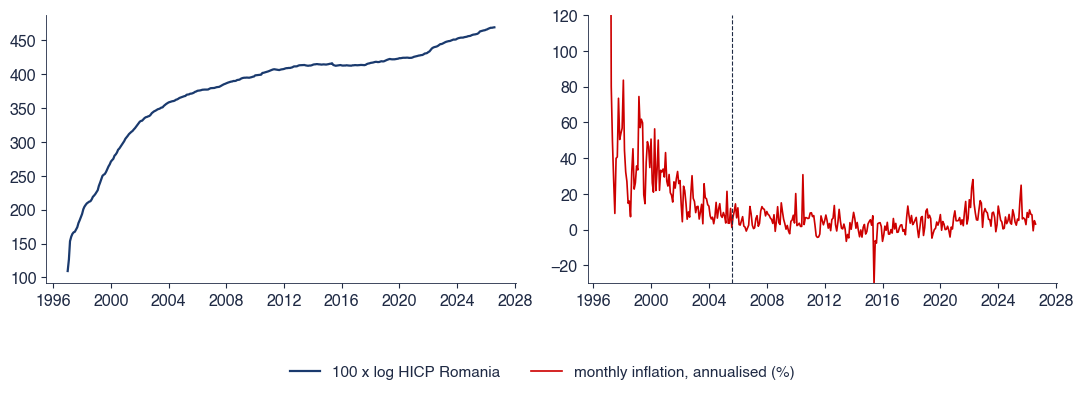

{'t_all': -4.249197925106882, 't_it': -2.393215920947131, 't_d2': -6.133528913200665, 'first': '1997-01-01', 'last': '2026-08-01', 'cv5': -2.87}


In [9]:
def adf_t(y, lags=1, trend=False, extra=None):
    """t-ratio of rho in dy_t = a (+ b t) + rho y_{t-1} + sum_j g_j dy_{t-j} (+ extra regressors) + e_t."""
    y = np.asarray(y, float)
    dy = np.diff(y)
    T = len(dy)
    rows = np.arange(lags, T)
    X = [np.ones(len(rows)), y[rows]]
    if trend:
        X.append(rows.astype(float))
    for j in range(1, lags + 1):
        X.append(dy[rows - j])
    if extra is not None:
        X += [np.asarray(c, float)[rows] for c in extra]
    X = np.column_stack(X)
    b, V, u = ols(dy[rows], X)
    return float(b[1] / np.sqrt(V[1, 1])), u


def fig_i2(save_it=True):
    """The I(2) question for the Romanian price level: log HICP, its first and second differences; ADF tests."""
    p = read_eurostat('prc_hicp_minr', 'M.I25.TOTAL.RO')
    lp = 100 * np.log(p.loc['1997-01-01':'2026-08-01'])
    d1 = lp.diff().dropna()
    d2 = d1.diff().dropna()
    t_all, _ = adf_t(d1.values, lags=12)
    t_it, _ = adf_t(d1.loc['2005-08-01':].values, lags=12)
    t_d2, _ = adf_t(d2.loc['2005-08-01':].values, lags=12)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
    axs[0].plot(lp.index, lp, color=st.MainBlue, lw=1.6, label='100 x log HICP Romania')
    axs[1].plot(d1.index, 12 * d1, color=st.IDAred, lw=1.2, label='monthly inflation, annualised (%)')
    axs[1].axvline(pd.Timestamp('2005-08-01'), color=st.DarkText, lw=0.8, ls='--')
    axs[1].set_ylim(-30, 120)
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch4_i2', save_it)
    return dict(t_all=t_all, t_it=t_it, t_d2=t_d2, first=str(lp.index[0].date()), last=str(lp.index[-1].date()),
                cv5=-2.87)


print(fig_i2(save_it=False))

## 5. Common trends: King, Plosser, Stock and Watson (1991)

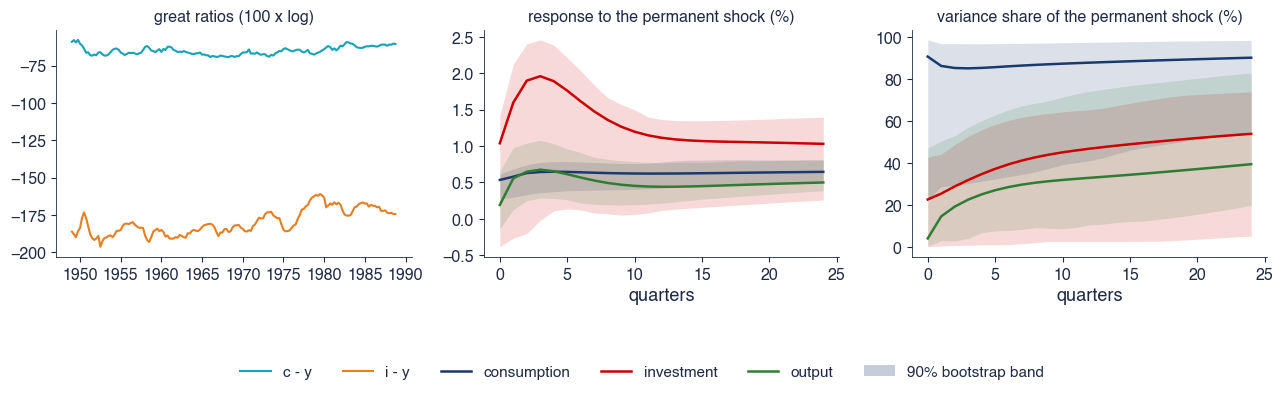

{'T': 160, 'p': 2, 'trace': [45.82342381922746, 19.405428855850033, 1.3702535901861734], 'lr': 16.562335076671665, 'plr': 0.0002532413583710147, 'lr4': 0.5011284370699153, 'plr4': 0.7783614931739614, 'share': {'c': [0.9084578403175684, 0.8523791034059881, 0.8657826832896259, 0.8772462627980904, 0.9015171037249076], 'i': [0.22672946939096103, 0.3197037135672815, 0.4128760751016095, 0.46083397108701074, 0.5353749920953002], 'y': [0.040750392126694596, 0.22597146537150647, 0.29787157298015, 0.3251533056087859, 0.3892335916260681]}}


In [10]:
def kpsw_data(start=KPSW['start'], end=KPSW['end']):
    """King, Plosser, Stock and Watson (1991) variables, quarterly: 100 x log of real per capita consumption of
    nondurables and services, gross private domestic fixed investment and output (FRED: PCND + PCESV, FPI, GDP,
    deflated by the GDP deflator GDPDEF, divided by population B230RC0Q173SBEA)."""
    f = read_fred(['PCND', 'PCESV', 'FPI', 'GDP', 'GDPDEF', 'B230RC0Q173SBEA']).dropna()
    real = lambda x: x / (f['GDPDEF'] / 100) / f['B230RC0Q173SBEA']   # noqa: E731
    d = pd.DataFrame({'c': 100 * np.log(real(f['PCND'] + f['PCESV'])), 'i': 100 * np.log(real(f['FPI'])),
                      'y': 100 * np.log(real(f['GDP']))})
    return d.loc[start:end]


def permanent_shock(alpha, Omega):
    """With n - r = 1 common trend, the permanent shock is proportional to alpha_perp' u_t:
    eps_P = alpha_perp' u_t / sd, impact column b_P = Omega alpha_perp (alpha_perp' Omega alpha_perp)^{-1/2}."""
    ap = perp(alpha)[:, 0]
    return Omega @ ap / np.sqrt(ap @ Omega @ ap)


def common_trend_irf(m, H):
    """Responses of the levels to the permanent shock (sign: positive long-run effect on the last variable) and the
    share of the permanent shock in the h-step forecast error variance of each level."""
    n, p = m['j']['n'], m['p']
    A = var_from_vecm(m['alpha'], m['beta'][:n], m['G'], p, n)
    Phi = ma_coefs(A, H)
    b = permanent_shock(m['alpha'], m['Omega'])
    C = granger_C(m['alpha'], m['beta'][:n], m['G'], p, n)
    if (C @ b)[-1] < 0:
        b = -b
    resp = np.einsum('hij,j->hi', Phi, b)
    tot = np.cumsum(np.einsum('hij,jk,hlk->hil', Phi, m['Omega'], Phi).diagonal(axis1=1, axis2=2), axis=0)
    share = np.cumsum(resp ** 2, axis=0) / tot
    return resp, share, C @ b, b


def kpsw_model(d, p, case=KPSW['case']):
    """VECM with the KPSW cointegrating vectors (great ratios c - y and i - y) imposed: rank 2, case 3."""
    beta = np.array([[1.0, 0.0], [0.0, 1.0], [-1.0, -1.0]])
    return vecm_fit(d[['c', 'i', 'y']].values, p, 2, case, beta=beta)


def vecm_bootstrap(m, stat, B=200, seed=SEED, wild=False):
    """Residual (i.i.d. resampling) or wild (Rademacher) bootstrap of a fitted VECM with beta fixed at the
    estimate: data regenerated recursively, the model refitted, stat(m_b) collected."""
    rng = np.random.default_rng(seed)
    U = m['U'] - m['U'].mean(axis=0)
    T = len(U)
    out = []
    for _ in range(B):
        e = U[rng.integers(0, T, T)] if not wild else m['U'] * rng.choice([-1.0, 1.0], (T, 1))
        Yb = vecm_simulate(m, e)
        mb = vecm_fit(Yb, m['p'], m['r'], m['case'], exog=m['exog'], beta=m['beta'])
        out.append(stat(mb))
    return out


def fig_kpsw(save_it=True, B=300):
    """KPSW (1991): the great ratios, the responses of c, i, y to the permanent shock and its variance shares, with
    residual-bootstrap bands (beta fixed at the great ratios)."""
    d = kpsw_data()
    Y = d[['c', 'i', 'y']].values
    ic = lag_select(Y, KPSW['pmax'])
    p = ic['bic']
    j = johansen(Y, p, 3)
    tab = crit_table()
    tab4 = tab
    lr = lr_beta(j, 2, np.array([[1, 0], [0, 1], [-1, -1.0]]))
    m = kpsw_model(d, p)
    H = KPSW['H']
    resp, share, lrun, b = common_trend_irf(m, H)
    draws = vecm_bootstrap(m, lambda mb: np.concatenate([common_trend_irf(mb, H)[0].ravel(), common_trend_irf(mb, H)[1].ravel()]), B=B)
    draws = np.array(draws)
    nr = (H + 1) * 3
    rlo, rhi = np.quantile(draws[:, :nr], [0.05, 0.95], axis=0)
    slo, shi = np.quantile(draws[:, nr:], [0.05, 0.95], axis=0)
    rlo, rhi, slo, shi = (x.reshape(H + 1, 3) for x in (rlo, rhi, slo, shi))
    # robustness: great ratios stationary around a linear trend (case 4, restricted trend)
    j4 = johansen(Y, p, 4)
    e4 = np.eye(4)
    fr = np.zeros((4, 1))
    fr[3, 0] = 1
    r4 = restricted_ml(j4, 2, [fr, fr], [e4[0] - e4[2], e4[1] - e4[2]])
    m4 = vecm_fit(Y, p, 2, 4, beta=r4['beta'])
    _, share_e, lrun_e, _ = common_trend_irf(m4, H)
    # extended samples
    ext = {}
    for end in ('2019-10-01', '2025-10-01'):
        de = kpsw_data(end=end)
        je = johansen(de[['c', 'i', 'y']].values, p, 3)
        _, se_, _, _ = common_trend_irf(kpsw_model(de, p), H)
        ext[end[:4]] = dict(share_y=[float(se_[h, 2]) for h in (0, 3, 7, 23)], trace=je['trace'].tolist(),
                            lr=float(lr_beta(je, 2, np.array([[1, 0], [0, 1], [-1, -1.0]]))), T=int(len(de)))
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
    ax = axs[0]
    ax.plot(d.index, d['c'] - d['y'], color=st.Teal, lw=1.5, label='c - y')
    ax.plot(d.index, d['i'] - d['y'], color=st.Orange, lw=1.5, label='i - y')
    ax.set_title('great ratios (100 x log)', fontsize=11.5)
    hh = np.arange(H + 1)
    names = ['consumption', 'investment', 'output']
    for k, (nm, c) in enumerate(zip(names, [st.MainBlue, st.IDAred, st.Forest])):
        axs[1].plot(hh, resp[:, k], color=c, lw=1.8, label=nm)
        axs[1].fill_between(hh, rlo[:, k], rhi[:, k], color=c, alpha=0.15, lw=0)
        axs[2].plot(hh, 100 * share[:, k], color=c, lw=1.8)
        axs[2].fill_between(hh, 100 * slo[:, k], 100 * shi[:, k], color=c, alpha=0.15, lw=0)
    axs[1].set_title('response to the permanent shock (%)', fontsize=11.5)
    axs[2].set_title('variance share of the permanent shock (%)', fontsize=11.5)
    for ax in axs[1:]:
        ax.set_xlabel('quarters')
    h1, l1 = axs[0].get_legend_handles_labels()
    h2, l2 = axs[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h1 + h2 + [patch(st.MainBlue)], l1 + l2 + ['90% bootstrap band'], ncol=6, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch4_kpsw', save_it)
    cy, iy = d['c'] - d['y'], d['i'] - d['y']
    return dict(T=int(len(d)), p=int(p), ic=ic, trace=j['trace'].tolist(), cv3=[tab[f'3|{m_}'][1] for m_ in (3, 2, 1)],
                lr=float(lr), plr=float(1 - stats.chi2.cdf(lr, 2)), lrun=lrun.tolist(), lrun_e=lrun_e.tolist(),
                share={nm: [float(share[h, k]) for h in (0, 3, 7, 11, 23)] for k, nm in enumerate(['c', 'i', 'y'])},
                share_lo={nm: [float(slo[h, k]) for h in (0, 3, 7, 11, 23)] for k, nm in enumerate(['c', 'i', 'y'])},
                share_hi={nm: [float(shi[h, k]) for h in (0, 3, 7, 11, 23)] for k, nm in enumerate(['c', 'i', 'y'])},
                share_e={nm: [float(share_e[h, k]) for h in (0, 3, 7, 11, 23)] for k, nm in enumerate(['c', 'i', 'y'])},
                trace4=j4['trace'].tolist(), cv4=[tab4[f'4|{m_}'][1] for m_ in (3, 2, 1)], lr4=r4['LR'],
                plr4=float(1 - stats.chi2.cdf(r4['LR'], 2)), tr4=r4['beta'][3].tolist(), ext=ext, cy_sd=float(cy.std()), iy_sd=float(iy.std()),
                cy_range=[float(cy.min()), float(cy.max())], resp0=resp[0].tolist(), B=B)


r = fig_kpsw(save_it=False, B=100)
print({k: r[k] for k in ('T', 'p', 'trace', 'lr', 'plr', 'lr4', 'plr4', 'share')})

## 6. ARDL and the bounds test

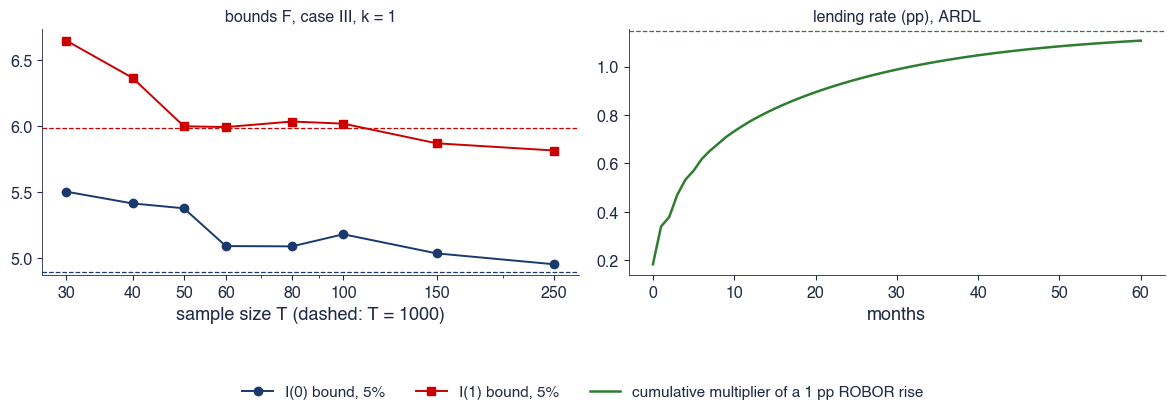

{'0.90': [4.119762492578205, 4.989697053419884], '0.95': [4.901172676202269, 5.985260469675356], '0.99': [6.816801838035567, 8.344240770826127]} {'p': 4, 'q': 2, 'F': 4.272722567134749, 't': -3.2838557613758423, 'theta': 1.1471698632359548, 'se': 0.12179774644482984, 'phi': -0.02565976588597689, 'se_phi': 0.007813913810643796, 'hl': 26.664921977468975, 'n': 244} {'p': 5, 'q': 3, 'F': 7.680768660147472, 't': -4.746639588965158, 'theta': 0.9395762923279368, 'se': 0.054917059176007366, 'phi': -0.0563261599761657, 'se_phi': 0.011866533980610414, 'hl': 11.956032680995303, 'n': 243}


In [11]:
def ardl_multipliers(r, H=60):
    """Cumulative dynamic multipliers of the ARDL in levels (response of y to a permanent unit rise of x)."""
    b, names = r['b'], r['names']
    p, q = r['p'], r['q']
    piy = b[names.index('y1')]
    pix = b[names.index('x1_0')]
    psi = [b[names.index(f'dy{i}')] for i in range(1, p)]
    om = [b[names.index(f'dx{j}_0')] for j in range(q)]
    # levels: y_t = (1 + piy) y_{t-1} + sum psi_i (y_{t-i} - y_{t-i-1}) + pix x_{t-1} + sum om_j (x_{t-j} - x_{t-j-1})
    x = np.ones(H + p + q + 2)
    x[:p + q + 1] = 0
    y = np.zeros_like(x)
    s0 = p + q + 1
    for t in range(1, len(x)):
        v = (1 + piy) * y[t - 1] + pix * x[t - 1]
        for i, ps in enumerate(psi, 1):
            if t - i - 1 >= 0:
                v += ps * (y[t - i] - y[t - i - 1])
        for jj, o in enumerate(om):
            if t - jj - 1 >= 0:
                v += o * (x[t - jj] - x[t - jj - 1])
        y[t] = v
    return y[s0:s0 + H + 1]


def fig_bounds(save_it=True, reps=NSIM):
    """Bounds test: asymptotic and small-sample 5% critical values (case III, k = 1, as in Narayan 2005) and the
    ARDL pass-through of ROBOR to the lending rate with its cumulative dynamic multipliers."""
    asym = {f'{c}|{k}': bounds_quantiles(k, c, T=1000, reps=reps) for c in (2, 3) for k in (1, 2, 3)}
    tq = bounds_quantiles(1, 3, T=1000, reps=reps, which='t')
    Ts = (30, 40, 50, 60, 80, 100, 150, 250)
    small = {T: bounds_quantiles(1, 3, T=T, reps=reps) for T in Ts}
    d = passthrough_data()
    r2 = ardl_select(d['lend'].values, d[['mm']].values, 6, 6, 2, 'bic')
    r3 = ardl_ecm(d['lend'].values, d[['mm']].values, r2['p'], r2['q'], 3)
    rd = ardl_select(d['dep'].values, d[['mm']].values, 6, 6, 2, 'bic')
    small_T = bounds_quantiles(1, 3, T=r3['n'], reps=reps)
    small_T2 = bounds_quantiles(1, 2, T=r2['n'], reps=reps)
    mult = ardl_multipliers(r2, 60)
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
    ax = axs[0]
    ax.plot(Ts, [small[T]['0.95'][0] for T in Ts], 'o-', color=st.MainBlue, label='I(0) bound, 5%')
    ax.plot(Ts, [small[T]['0.95'][1] for T in Ts], 's-', color=st.IDAred, label='I(1) bound, 5%')
    ax.axhline(asym['3|1']['0.95'][0], color=st.MainBlue, ls='--', lw=0.9)
    ax.axhline(asym['3|1']['0.95'][1], color=st.IDAred, ls='--', lw=0.9)
    ax.set_xscale('log')
    ax.set_xticks(Ts)
    ax.set_xticklabels([str(T) for T in Ts])
    ax.set_xlabel('sample size T (dashed: T = 1000)')
    ax.set_title('bounds F, case III, k = 1', fontsize=11.5)
    hh = np.arange(61)
    axs[1].plot(hh, mult, color=st.Forest, lw=1.8, label='cumulative multiplier of a 1 pp ROBOR rise')
    axs[1].axhline(r2['theta'][0], color=st.Forest, ls='--', lw=0.9)
    axs[1].set_xlabel('months')
    axs[1].set_title('lending rate (pp), ARDL', fontsize=11.5)
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch4_bounds', save_it)
    def pk(r):
        return dict(p=r['p'], q=r['q'], F=r['F'], t=r['t'], theta=float(r['theta'][0]), se=float(r['se_theta'][0]),
                    phi=r['phi'], se_phi=r['se_phi'], hl=r['halflife'], n=r['n'])
    return dict(asym=asym, tq=tq, small={str(k): v for k, v in small.items()}, small_T=small_T, small_T2=small_T2,
                lend2=pk(r2), lend3=pk(r3), dep2=pk(rd), mult=[float(mult[h]) for h in (0, 1, 3, 6, 12, 24, 36, 60)],
                reps=reps)


r = fig_bounds(save_it=False, reps=2000)
print(r['asym']['3|1'], r['lend2'], r['dep2'])

## 7. Panel time series: EU-27 consumption, income and inflation

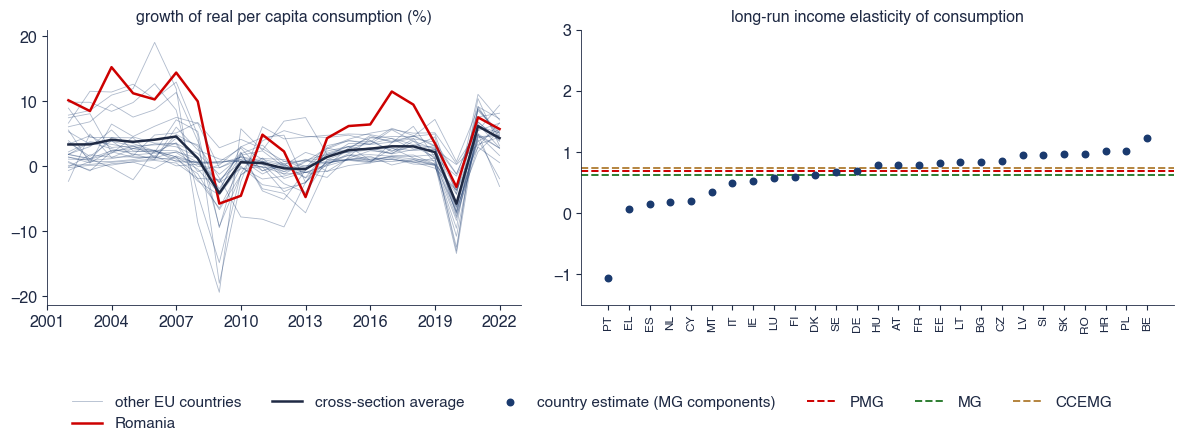

{'N': 27, 'T': 22, 'cd': {'c': {'CD': 50.29084398259308, 'p': 0.0, 'mean_abs_rho': 0.5857681019211106}, 'y': {'CD': 25.72146246117865, 'p': 0.0, 'mean_abs_rho': 0.33777175006865323}, 'pi': {'CD': 62.396243398521534, 'p': 0.0, 'mean_abs_rho': 0.7100575422589134}}, 'ped': {'stat': -3.047181616737036, 'p': 0.0, 'cv5': -2.7662257810219244}, 'wgt': {'stat': -1.6558536073831556, 'p': 0.685, 'cv5': -2.151819759017287}, 'mg': {'theta': [0.6267852756296202, 0.8156198947374664], 'se': [0.08627385909928761, 0.323301346402789], 'phi': -0.42635869137725124, 'phi_se': 0.032202870973396316}, 'pmg': {'theta': [0.6940457280162082, 0.4128522554380014], 'se': [0.04065311954594789, 0.17950608730802248], 'phi': -0.31282177545579537, 'phi_se': 0.027547363618144576}, 'cce': {'theta': [0.7313475878804131, 0.10456586840982657], 'se': [0.04847851437589489, 0.09952065695431325], 'phi': nan, 'phi_se': nan}, 'H': 2.406679884814528, 'pH': 0.30018991866540834}


In [12]:
def eu_panel(start=PANEL['start'], end=PANEL['end']):
    """EU-27 annual panel (Eurostat): c = 100 log real per capita final consumption of households and NPISH,
    y = 100 log real per capita gross disposable income of households and NPISH (both deflated by the consumption
    deflator), pi = 100 x change in the log consumption deflator. National currency, 1995 onward."""
    def es(key):
        url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{key}?format=SDMX-CSV'
               f'&startPeriod={start - 1}&endPeriod={end}')
        t = pd.read_csv(pd.io.common.BytesIO(get_bytes(url)))
        return t
    cons = es('nama_10_gdp/A.CP_MNAC.P31_S14_S15.')
    defl = es('nama_10_gdp/A.PD15_NAC.P31_S14_S15.')
    inc = es('nasa_10_nf_tr/A.CP_MNAC..B6G.S14_S15.')
    pop = es('nama_10_pe/A.THS_PER.POP_NC.')
    inc = inc[inc['direct'] == inc['direct'].iloc[0]]
    rows = []
    for g in EU27:
        def s(t):
            u = t[t['geo'] == g]
            return pd.Series(pd.to_numeric(u['OBS_VALUE'], errors='coerce').values, index=u['TIME_PERIOD'].astype(int))
        dfl = s(defl)
        c = 100 * np.log(s(cons) / dfl * 100 / s(pop))
        y = 100 * np.log(s(inc) / dfl * 100 / s(pop))
        pi = 100 * np.log(dfl).diff()
        d = pd.concat([c, y, pi], axis=1, keys=['c', 'y', 'pi']).loc[start:end].dropna()
        d['geo'] = g
        rows.append(d)
    out = pd.concat(rows)
    out.index.name = 'year'
    return out.reset_index()


def hicp_panel(start=1997, end=2025):
    """EU-27 annual HICP inflation (Eurostat prc_hicp_aind, annual average rate of change, %)."""
    url = ('https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/prc_hicp_aind/A.RCH_A_AVG.CP00.'
           f'?format=SDMX-CSV&startPeriod={start}&endPeriod={end}')
    t = pd.read_csv(pd.io.common.BytesIO(get_bytes(url)))
    t = t[t['geo'].isin(EU27)]
    return t.pivot(index='TIME_PERIOD', columns='geo', values='OBS_VALUE')[EU27].astype(float)


def wide(df, var):
    """Balanced T x N matrix of one variable of a long panel (columns = countries)."""
    return df.pivot(index='year', columns='geo', values=var).dropna(axis=0, how='any')


def cd_test(E):
    """Pesaran (2004, 2021) CD statistic of a T x N matrix of residuals (pairwise complete): sqrt(2/(N(N-1)))
    sum_{i<j} sqrt(T_ij) rho_ij -> N(0, 1) under weak dependence; also the average |rho_ij|."""
    E = np.asarray(E, float)
    N = E.shape[1]
    s, a, k = 0.0, 0.0, 0
    for i in range(N):
        for j in range(i + 1, N):
            ok = ~np.isnan(E[:, i]) & ~np.isnan(E[:, j])
            if ok.sum() < 4:
                continue
            r = np.corrcoef(E[ok, i], E[ok, j])[0, 1]
            s += np.sqrt(ok.sum()) * r
            a += abs(r)
            k += 1
    CD = np.sqrt(2.0 / (N * (N - 1))) * s
    return dict(CD=float(CD), p=float(2 * (1 - stats.norm.cdf(abs(CD)))), mean_abs_rho=float(a / k))


def ips_tbar(W, lags=1, trend=False):
    """Im-Pesaran-Shin (2003) t-bar: the average of the individual ADF t-ratios (W: T x N)."""
    return float(np.mean([adf_t(W[:, i], lags, trend)[0] for i in range(W.shape[1])]))


def cips(W, lags=1, trend=False):
    """Pesaran (2007) CIPS: the average of the CADF t-ratios, each ADF regression augmented with the lagged level
    and the current and lagged differences of the cross-section average."""
    W = np.asarray(W, float)
    ybar = W.mean(axis=1)
    dbar = np.diff(ybar)
    out = []
    for i in range(W.shape[1]):
        # extra regressors aligned with dy (length T-1): ybar_{t-1}, dybar_t, dybar_{t-j}
        ex = [ybar[:-1], dbar] + [np.concatenate([np.full(j, np.nan), dbar[:-j]]) for j in range(1, lags + 1)]
        y = W[:, i]
        dy = np.diff(y)
        T = len(dy)
        rows = np.arange(lags, T)
        X = [np.ones(len(rows)), y[rows]]
        if trend:
            X.append(rows.astype(float))
        for j in range(1, lags + 1):
            X.append(dy[rows - j])
        X += [e[rows] for e in ex]
        X = np.column_stack(X)
        b, V, u = ols(dy[rows], X)
        out.append(b[1] / np.sqrt(V[1, 1]))
    return float(np.mean(out)), np.array(out)


def llc_t(W, lags=1, trend=False):
    """Levin-Lin-Chu (2002) pooled t-ratio: orthogonalised and variance-normalised ADF residuals, one pooled rho."""
    W = np.asarray(W, float)
    E, Vv = [], []
    for i in range(W.shape[1]):
        y = W[:, i]
        dy = np.diff(y)
        T = len(dy)
        rows = np.arange(lags, T)
        Z = [np.ones(len(rows))] + ([rows.astype(float)] if trend else []) + [dy[rows - j] for j in range(1, lags + 1)]
        Z = np.column_stack(Z)
        e = dy[rows] - Z @ np.linalg.lstsq(Z, dy[rows], rcond=None)[0]
        v = y[rows] - Z @ np.linalg.lstsq(Z, y[rows], rcond=None)[0]
        s = np.sqrt(np.sum((e - (e @ v / (v @ v)) * v) ** 2) / (len(e) - Z.shape[1] - 1))
        E.append(e / s)
        Vv.append(v / s)
    e, v = np.concatenate(E), np.concatenate(Vv)
    rho = e @ v / (v @ v)
    se = np.sqrt(np.sum((e - rho * v) ** 2) / (len(e) - 1) / (v @ v))
    return float(rho / se)


def panel_null(stat, N, T, reps=2000, seed=SEED, **kw):
    """Null distribution of a panel unit-root statistic: N independent Gaussian random walks of length T."""
    rng = np.random.default_rng(seed + N + T)
    out = np.empty(reps)
    for r in range(reps):
        W = np.cumsum(rng.standard_normal((T, N)), axis=0)
        v = stat(W, **kw)
        out[r] = v[0] if isinstance(v, tuple) else v
    return out


def pedroni_group_adf(Yw, Xw, lags=1, trend=False):
    """Pedroni (1999, 2004) group-mean ADF statistic: the average ADF t-ratio of the residuals of the individual
    cointegrating regressions y_it = a_i (+ d_i t) + b_i' x_it + e_it (raw average; the null distribution is
    simulated, which replaces the tabulated mean and variance adjustment)."""
    out = []
    for i in range(Yw.shape[1]):
        X = [np.ones(len(Yw))] + ([np.arange(len(Yw), dtype=float)] if trend else []) + [x[:, i] for x in Xw]
        X = np.column_stack(X)
        e = Yw[:, i] - X @ np.linalg.lstsq(X, Yw[:, i], rcond=None)[0]
        de = np.diff(e)
        T = len(de)
        rows = np.arange(lags, T)
        Z = np.column_stack([e[rows]] + [de[rows - j] for j in range(1, lags + 1)])
        b, V, u = ols(de[rows], Z)
        out.append(b[0] / np.sqrt(V[0, 0]))
    return float(np.mean(out))


def westerlund_gt(Yw, Xw, lags=1):
    """Westerlund (2007) group-mean Gt statistic: the average t-ratio of the error-correction coefficient alpha_i in
    dy_it = d_i + alpha_i y_{i,t-1} + lambda_i' x_{i,t-1} + sum_j a_ij dy_{i,t-j} + sum_j g_ij' dx_{i,t-j} + e_it."""
    out = []
    for i in range(Yw.shape[1]):
        y = Yw[:, i]
        xs = [x[:, i] for x in Xw]
        dy = np.diff(y)
        dxs = [np.diff(x) for x in xs]
        T = len(dy)
        rows = np.arange(lags, T)
        Z = [np.ones(len(rows)), y[rows]] + [x[rows] for x in xs] + [dy[rows - j] for j in range(1, lags + 1)]
        Z += [d[rows - j] for d in dxs for j in range(0, lags + 1)]
        Z = np.column_stack(Z)
        b, V, u = ols(dy[rows], Z)
        out.append(b[1] / np.sqrt(V[1, 1]))
    return float(np.mean(out))


def coint_null(stat, N, T, k, reps=1000, seed=SEED, **kw):
    """Null of no cointegration: y and k regressors independent random walks in each of N independent units."""
    rng = np.random.default_rng(seed + 7 * N + T + k)
    out = np.empty(reps)
    for r in range(reps):
        Y = np.cumsum(rng.standard_normal((T, N)), axis=0)
        X = [np.cumsum(rng.standard_normal((T, N)), axis=0) for _ in range(k)]
        out[r] = stat(Y, X, **kw)
    return out


def ecm_unit(d, theta=None):
    """One country of the ARDL(1,1,1) consumption model in error-correction form (PSS 1999):
    dc_t = mu + phi (c_{t-1} - theta_1 y_{t-1} - theta_2 pi_{t-1}) + d1 dy_t + d2 dpi_t + e_t.
    With theta None: unrestricted OLS of dc on (1, c_{t-1}, y_{t-1}, pi_{t-1}, dy_t, dpi_t)."""
    c, y, pi = d['c'].values, d['y'].values, d['pi'].values
    dc, dyv, dpi = np.diff(c), np.diff(y), np.diff(pi)
    if theta is None:
        X = np.column_stack([np.ones(len(dc)), c[:-1], y[:-1], pi[:-1], dyv, dpi])
    else:
        ec = c[:-1] - theta[0] * y[:-1] - theta[1] * pi[:-1]
        X = np.column_stack([np.ones(len(dc)), ec, dyv, dpi])
    b, V, u = ols(dc, X)
    return b, V, u


def mean_group(P):
    """Pesaran-Smith (1995) mean group: country long-run coefficients -b_x/b_c averaged; SE = sd / sqrt(N)."""
    th, ph = [], []
    for g, d in P.groupby('geo'):
        b, V, u = ecm_unit(d)
        th.append([-b[2] / b[1], -b[3] / b[1]])
        ph.append(b[1])
    th = np.array(th)
    N = len(th)
    est = th.mean(axis=0)
    Vmg = np.cov(th.T) / N
    return dict(theta=est, se=np.sqrt(np.diag(Vmg)), V=Vmg, phi=float(np.mean(ph)), phi_se=float(np.std(ph, ddof=1) / np.sqrt(N)),
                thetas=th, phis=np.array(ph))


def pmg(P, x0=None):
    """Pesaran-Shin-Smith (1999) pooled mean group: common long-run theta, country-specific short run and
    variances; ML by maximising the concentrated log-likelihood -sum_i T_i/2 log sigma_i^2(theta); standard errors
    from the numerical Hessian of the concentrated likelihood."""
    groups = [d for _, d in P.groupby('geo')]

    def nll(th):
        s = 0.0
        for d in groups:
            b, V, u = ecm_unit(d, th)
            s += len(u) / 2 * np.log(u @ u / len(u))
        return s
    mg = mean_group(P)
    res = optimize.minimize(nll, mg['theta'] if x0 is None else x0, method='Nelder-Mead',
                            options=dict(xatol=1e-8, fatol=1e-10, maxiter=4000))
    th = res.x
    h = 1e-4
    Hm = np.zeros((2, 2))
    for a in range(2):
        for c in range(2):
            ea, ec_ = np.eye(2)[a] * h, np.eye(2)[c] * h
            Hm[a, c] = (nll(th + ea + ec_) - nll(th + ea - ec_) - nll(th - ea + ec_) + nll(th - ea - ec_)) / (4 * h * h)
    Vp = np.linalg.inv(Hm)
    phis = [ecm_unit(d, th)[0][1] for d in groups]
    return dict(theta=th, se=np.sqrt(np.diag(Vp)), V=Vp, phi=float(np.mean(phis)),
                phi_se=float(np.std(phis, ddof=1) / np.sqrt(len(phis))), phis=np.array(phis), nll=float(res.fun))


def dfe(P):
    """Dynamic fixed effects: pooled ECM with country intercepts and common slopes; delta-method SE clustered by
    country."""
    rows, ids = [], []
    for k, (g, d) in enumerate(P.groupby('geo')):
        c, y, pi = d['c'].values, d['y'].values, d['pi'].values
        X = np.column_stack([c[:-1], y[:-1], pi[:-1], np.diff(y), np.diff(pi)])
        rows.append(np.column_stack([np.diff(c), X]))
        ids += [k] * len(X)
    Z = np.vstack(rows)
    ids = np.array(ids)
    D = (ids[:, None] == np.unique(ids)[None, :]).astype(float)
    X = np.hstack([Z[:, 1:], D])
    b = np.linalg.lstsq(X, Z[:, 0], rcond=None)[0]
    u = Z[:, 0] - X @ b
    XtXi = np.linalg.inv(X.T @ X)
    meat = sum(np.outer(X[ids == k].T @ u[ids == k], X[ids == k].T @ u[ids == k]) for k in np.unique(ids))
    V = XtXi @ meat @ XtXi
    th = np.array([-b[1] / b[0], -b[2] / b[0]])
    G = np.zeros((2, len(b)))
    G[0, 0], G[0, 1] = b[1] / b[0] ** 2, -1 / b[0]
    G[1, 0], G[1, 2] = b[2] / b[0] ** 2, -1 / b[0]
    Vt = G @ V @ G.T
    return dict(theta=th, se=np.sqrt(np.diag(Vt)), phi=float(b[0]), phi_se=float(np.sqrt(V[0, 0])))


def ccemg(P):
    """Pesaran (2006) common correlated effects mean group in levels: each country regression of c on (1, y, pi)
    augmented with the cross-section averages of c, y, pi; slopes averaged (valid with non-stationary common
    factors, Kapetanios, Pesaran and Yamagata 2011)."""
    bar = P.groupby('year')[['c', 'y', 'pi']].mean()
    th = []
    for g, d in P.groupby('geo'):
        a = bar.loc[d['year']]
        X = np.column_stack([np.ones(len(d)), d['y'], d['pi'], a['c'], a['y'], a['pi']])
        b = np.linalg.lstsq(X, d['c'].values, rcond=None)[0]
        th.append(b[1:3])
    th = np.array(th)
    return dict(theta=th.mean(axis=0), se=th.std(axis=0, ddof=1) / np.sqrt(len(th)), thetas=th)


def dols_mg(P, k=1):
    """Group-mean panel DOLS (Pedroni 2001; Stock and Watson 1993): country DOLS of c on (1, y, pi) with leads and
    lags of the differences of y and pi (k each), slopes averaged."""
    th = []
    for g, d in P.groupby('geo'):
        c, y, pi = d['c'].values, d['y'].values, d['pi'].values
        dyv, dpi = np.diff(y, prepend=np.nan), np.diff(pi, prepend=np.nan)
        rows = np.arange(k + 1, len(c) - k)
        X = [np.ones(len(rows)), y[rows], pi[rows]]
        for j in range(-k, k + 1):
            X += [dyv[rows + j], dpi[rows + j]]
        X = np.column_stack(X)
        b = np.linalg.lstsq(X, c[rows], rcond=None)[0]
        th.append(b[1:3])
    th = np.array(th)
    return dict(theta=th.mean(axis=0), se=th.std(axis=0, ddof=1) / np.sqrt(len(th)), thetas=th)


def hausman(a, b):
    """Hausman statistic (theta_MG - theta_PMG)' (V_MG - V_PMG)^{-1} (theta_MG - theta_PMG) ~ chi2(k)."""
    d = a['theta'] - b['theta']
    Vd = a['V'] - b['V']
    H = float(d @ np.linalg.pinv(Vd) @ d)
    return H, float(1 - stats.chi2.cdf(H, len(d)))


def fig_panel(save_it=True, reps=1000):
    """EU-27 consumption, income and inflation: cross-section dependence, panel unit roots, panel cointegration,
    MG, PMG, DFE, group-mean DOLS and CCEMG long-run coefficients."""
    P = eu_panel(start=2000)
    Wc, Wy, Wp = (wide(P, v) for v in ('c', 'y', 'pi'))
    N, T = Wc.shape[1], Wc.shape[0]
    cd = {v: cd_test(np.diff(W.values, axis=0)) for v, W in (('c', Wc), ('y', Wy))}
    cd['pi'] = cd_test(Wp.values - Wp.values.mean(axis=0))
    ur = {}
    for v, W, tr in (('c', Wc, True), ('y', Wy, True), ('pi', Wp, False)):
        for nm, f in (('llc', llc_t), ('ips', ips_tbar), ('cips', cips)):
            s = f(W.values, lags=1, trend=tr)
            s = s[0] if isinstance(s, tuple) else s
            nul = panel_null(f, N, T, reps=reps, lags=1, trend=tr)
            ur[f'{v}.{nm}'] = dict(stat=float(s), p=float(np.mean(nul <= s)), cv5=float(np.quantile(nul, 0.05)))
    ped = pedroni_group_adf(Wc.values, [Wy.values, Wp.values])
    wgt = westerlund_gt(Wc.values, [Wy.values, Wp.values])
    nped = coint_null(pedroni_group_adf, N, T, 2, reps=reps)
    nwgt = coint_null(westerlund_gt, N, T, 2, reps=reps)
    mg, pm, fe, cc, do = mean_group(P), pmg(P), dfe(P), ccemg(P), dols_mg(P)
    H, pH = hausman(mg, pm)
    # residual CD of the PMG model
    E = []
    for g_, dd in P.groupby('geo'):
        _, _, u = ecm_unit(dd, pm['theta'])
        E.append(pd.Series(u, index=dd['year'].values[1:], name=g_))
    E = pd.concat(E, axis=1)
    cd_pmg = cd_test(E.values)
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw=dict(width_ratios=[1.0, 1.25]))
    gC = Wc.diff().dropna()
    for i, gname in enumerate(gC.columns):
        axs[0].plot(gC.index, gC[gname], color=st.MainBlue if gname != 'RO' else st.IDAred,
                    lw=0.6 if gname != 'RO' else 1.8, alpha=0.35 if gname != 'RO' else 1.0,
                    label='Romania' if gname == 'RO' else ('other EU countries' if i == 0 else '_'))
    axs[0].plot(gC.index, gC.mean(axis=1), color=st.DarkText, lw=1.8, label='cross-section average')
    axs[0].set_title('growth of real per capita consumption (%)', fontsize=11.5)
    axs[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    th = mg['thetas'][:, 0]
    o = np.argsort(th)
    geos = sorted(P['geo'].unique())
    axs[1].scatter(np.arange(N), th[o], color=st.MainBlue, s=22, zorder=3, label='country estimate (MG components)')
    axs[1].set_xticks(np.arange(N))
    axs[1].set_xticklabels([geos[i] for i in o], rotation=90, fontsize=8.5)
    for val, c, lab in ((pm['theta'][0], st.IDAred, 'PMG'), (mg['theta'][0], st.Forest, 'MG'), (cc['theta'][0], st.Amber, 'CCEMG')):
        axs[1].axhline(val, color=c, lw=1.4, ls='--', label=lab)
    axs[1].set_title('long-run income elasticity of consumption', fontsize=11.5)
    axs[1].set_ylim(-1.5, 3.0)
    st.fig_legend_bottom(fig, ncol=6, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch4_panel', save_it)
    def pk(r):
        return dict(theta=[float(x) for x in r['theta']], se=[float(x) for x in r['se']],
                    phi=float(r.get('phi', np.nan)), phi_se=float(r.get('phi_se', np.nan)))
    return dict(N=int(N), T=int(T), first=int(Wc.index[0]), last=int(Wc.index[-1]), nobs=int(len(P)), cd=cd, ur=ur,
                ped=dict(stat=ped, p=float(np.mean(nped <= ped)), cv5=float(np.quantile(nped, 0.05))),
                wgt=dict(stat=wgt, p=float(np.mean(nwgt <= wgt)), cv5=float(np.quantile(nwgt, 0.05))),
                mg=pk(mg), pmg=pk(pm), dfe=pk(fe), cce=pk(cc), dols=pk(do), H=H, pH=pH, cd_pmg=cd_pmg,
                th_min=float(th.min()), th_max=float(th.max()), th_ro=float(mg['thetas'][geos.index('RO'), 0]),
                n_neg_phi=int((mg['phis'] >= 0).sum()), reps=reps)


r = fig_panel(save_it=False, reps=200)
print({k: r[k] for k in ('N', 'T', 'cd', 'ped', 'wgt', 'mg', 'pmg', 'cce', 'H', 'pH')})

## 8. AI mini-case: how robust is the verdict?

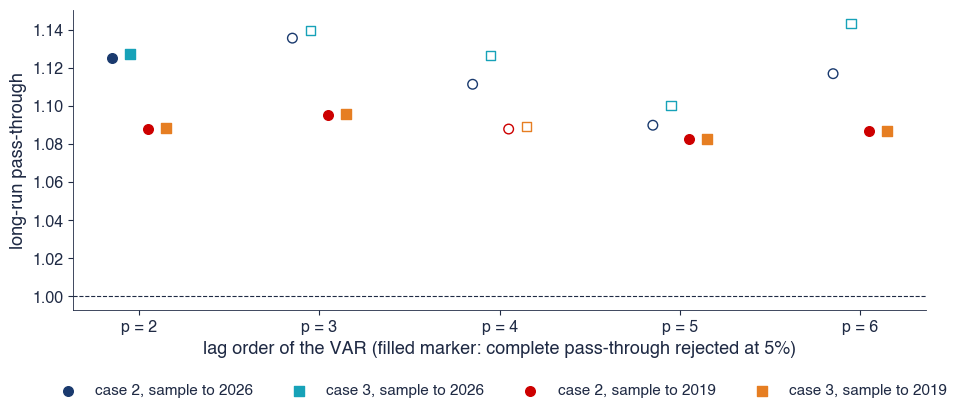

1.0825400601931647 1.1434217228413175 10 20


In [13]:
def fig_ai_case(save_it=True):
    """Robustness of one verdict: the long-run pass-through of ROBOR to the lending rate and the p-value of complete
    pass-through, across lag lengths, deterministic cases and samples."""
    rows = []
    for end, lab in (('2019-12-01', 'to 2019'), (PT['end'], 'to 2026')):
        d = passthrough_data(end=end)
        for case in (2, 3):
            for p in (2, 3, 4, 5, 6):
                r = passthrough_tests(d, p, case)
                rows.append(dict(sample=lab, case=case, p=p, theta=r['theta_l'], pl=r['pl']))
    t = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    xs = {p: i for i, p in enumerate((2, 3, 4, 5, 6))}
    for (lab, case), c, mk, off in ((('to 2026', 2), st.MainBlue, 'o', -0.15), (('to 2026', 3), st.Teal, 's', -0.05),
                                    (('to 2019', 2), st.IDAred, 'o', 0.05), (('to 2019', 3), st.Orange, 's', 0.15)):
        s = t[(t['sample'] == lab) & (t['case'] == case)]
        x = np.array([xs[p] for p in s['p']]) + off
        filled = s['pl'].values < 0.05
        ax.scatter(x[filled], s['theta'].values[filled], color=c, marker=mk, s=48, zorder=3,
                   label=f'case {case}, sample {lab}')
        ax.scatter(x[~filled], s['theta'].values[~filled], facecolors='none', edgecolors=c, marker=mk, s=48, zorder=3)
    ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_xticks(list(xs.values()))
    ax.set_xticklabels([f'p = {p}' for p in xs])
    ax.set_ylabel('long-run pass-through')
    ax.set_xlabel('lag order of the VAR (filled marker: complete pass-through rejected at 5%)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ats_ch4_ai_case', save_it)
    return dict(rows=rows, tmin=float(t['theta'].min()), tmax=float(t['theta'].max()), nrej=int((t['pl'] < 0.05).sum()),
                n=int(len(t)))


r = fig_ai_case(save_it=False)
print(r['tmin'], r['tmax'], r['nrej'], r['n'])

## Exercises

1. Re-estimate the pass-through VECM in case 3 and compare the critical values you need.
2. Add a shift dummy for 2008:10 to the unrestricted terms (`exog`) and redo the rank test.
3. Replace PMG by CCEMG with the inflation variable dropped: does the income elasticity move?